In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("antobenedetti/animals")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 882M/882M [00:04<00:00, 196MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/antobenedetti/animals/versions/5
Contents of base_path (/root/.cache/kagglehub/datasets/antobenedetti/animals/versions):
['5']
Contents of path (/root/.cache/kagglehub/datasets/antobenedetti/animals/versions/5):
['animals']


In [ ]:
import os

dataset_dir = os.path.join(path, 'animals')
sub_folders = ['train', 'val', 'inf']

for folder in sub_folders:
    folder_path = os.path.join(dataset_dir, folder)
    if os.path.exists(folder_path):
        animal_classes = [d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
        print(f"Folder '{folder}' contains {len(animal_classes)} animal classes.")
        print(f"Example classes: {animal_classes[:5]}\n")

Folder 'train' contains 5 animal classes.
Example classes: ['cat', 'lion', 'horse', 'elephant', 'dog']

Folder 'val' contains 5 animal classes.
Example classes: ['cat', 'lion', 'horse', 'elephant', 'dog']

Folder 'inf' contains 0 animal classes.
Example classes: []



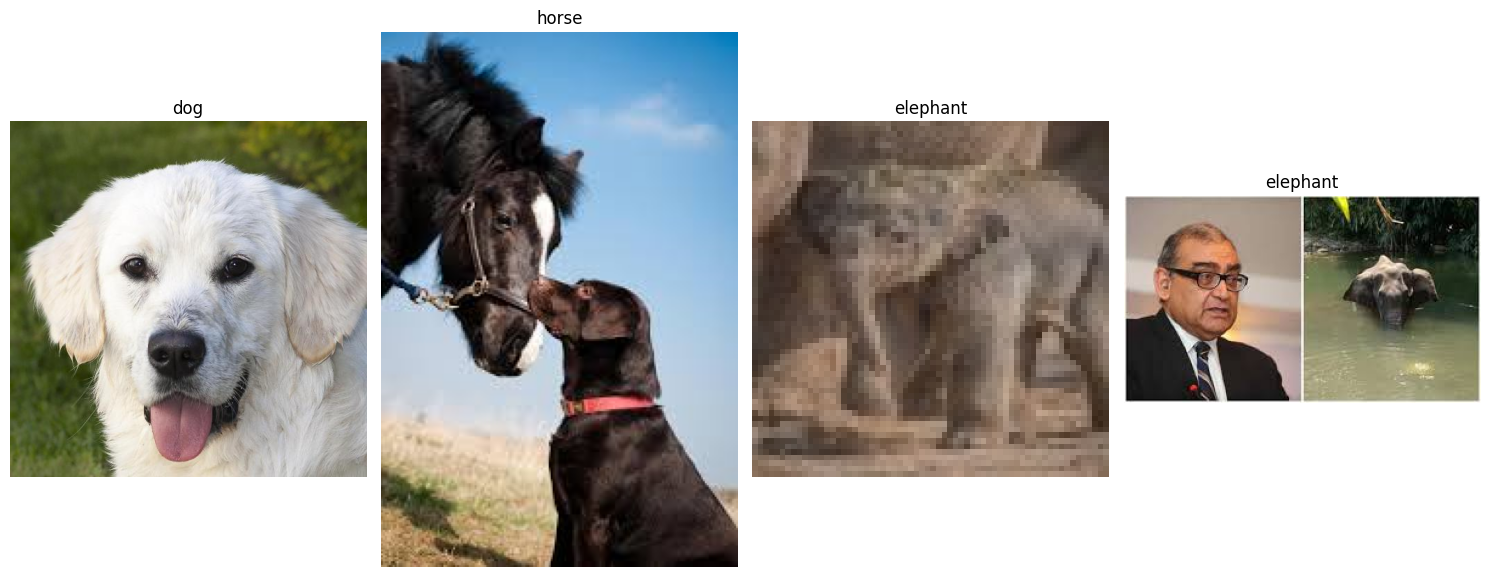

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

plt.figure(figsize=(15, 10))

train_dir = os.path.join(dataset_dir, 'train')
animal_types = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for i in range(4):
    selected_animal = random.choice(animal_types)
    animal_folder = os.path.join(train_dir, selected_animal)
    images = [f for f in os.listdir(animal_folder) if os.path.isfile(os.path.join(animal_folder, f))]

    if images:
        random_img = random.choice(images)
        img_path = os.path.join(animal_folder, random_img)
        img = mpimg.imread(img_path)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(selected_animal)
        plt.axis('off')

plt.tight_layout()
plt.show()

## GPU Check and Setup

In [ ]:
import tensorflow as tf

# Check for GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found {len(gpus)} GPU(s).")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled for GPUs.")
else:
    print("No GPU devices found. Training will run on CPU.")

# Verify TensorFlow version and GPU status
print("TensorFlow version:", tf.__version__)
print("Is GPU available:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Found 1 GPU(s).
Memory growth enabled for GPUs.
TensorFlow version: 2.20.0
Is GPU available: True


## Data Preparation for AlexNet

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image dimensions for AlexNet
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Define paths
train_dir = os.path.join(dataset_dir, 'train')
val_dir = os.path.join(dataset_dir, 'val')

# Data augmentation and preprocessing for training
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Preprocessing for validation (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")

Found 13474 images belonging to 5 classes.
Found 1497 images belonging to 5 classes.
Number of classes: 5


## Build AlexNet Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define the AlexNet model architecture
alexnet_model = Sequential([
    # Layer 1: Convolutional
    Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # Layer 2: Convolutional
    Conv2D(filters=256, kernel_size=(5,5), strides=(1,1), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # Layer 3: Convolutional
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),
    BatchNormalization(),

    # Layer 4: Convolutional
    Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),
    BatchNormalization(),

    # Layer 5: Convolutional
    Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # Flatten layer
    Flatten(),

    # Layer 6: Fully Connected
    Dense(4096, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),

    # Layer 7: Fully Connected
    Dense(4096, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),

    # Layer 8: Output Layer
    Dense(num_classes, activation='softmax') # num_classes should be determined from the data generator
])

# Compile the model
alexnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
alexnet_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 46,805,765 (178.55 MB)

 Trainable params: 46,786,629 (178.48 MB)

 Non-trainable params: 19,136 (74.75 KB)

## Train AlexNet Model

In [ ]:
EPOCHS = 10 # You can increase this for better performance

history = alexnet_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 210s 465ms/step - accuracy: 0.3121 - loss: 2.0747 - val_accuracy: 0.4293 - val_loss: 1.5425
Epoch 2/10
  1/421 ━━━━━━━━━━━━━━━━━━━━ 33s 80ms/step - accuracy: 0.3750 - loss: 1.8370

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.3750 - loss: 1.8370 - val_accuracy: 0.4212 - val_loss: 1.5634
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 237s 438ms/step - accuracy: 0.3730 - loss: 1.7295 - val_accuracy: 0.3798 - val_loss: 2.3327
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3750 - loss: 1.8699 - val_accuracy: 0.3567 - val_loss: 2.5500
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 181s 430ms/step - accuracy: 0.4246 - loss: 1.5557 - val_accuracy: 0.3302 - val_loss: 2.0370
Epoch 6/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4062 - loss: 1.3913 - val_accuracy: 0.3376 - val_loss: 1.9853
Epoch 7/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 186s 442ms/step - accuracy: 0.4757 - loss: 1.4429 - val_accuracy: 0.4300 - val_loss: 2.0580
Epoch 8/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5312 - loss: 1.2209 - val_accuracy: 0.4110 - val_loss: 2.2218
Epoch 9/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 194s 435ms/step - accuracy: 0.5628 - loss: 1.2038 - val_accur

## Summarize Training Results

In [ ]:
print("\nTraining Summary:")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")


Training Summary:
Final Training Accuracy: 0.6250
Final Validation Accuracy: 0.4524
Final Training Loss: 1.1822
Final Validation Loss: 2.1732


## Visualize Training History

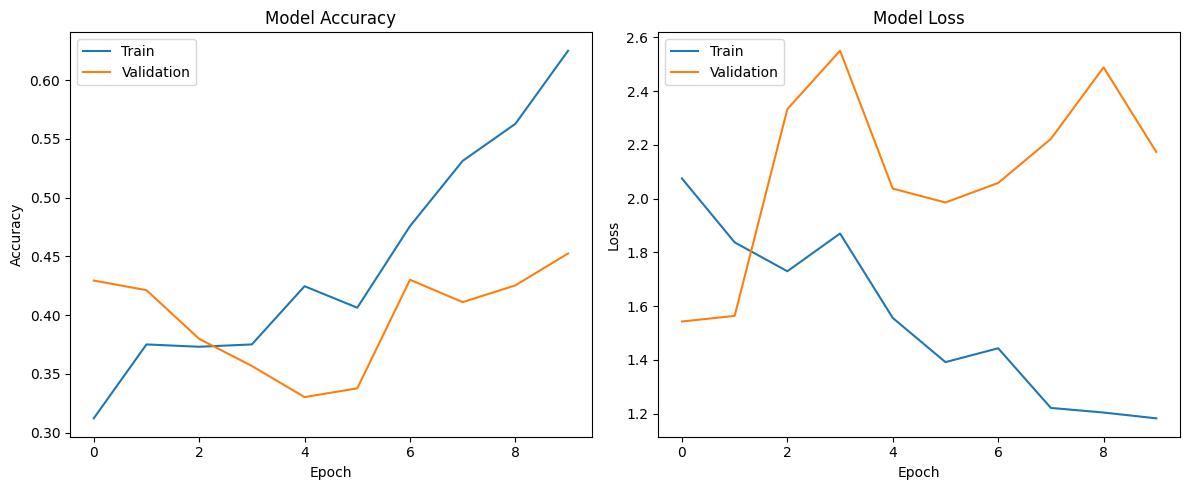

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()